In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import tensorflow as tf
import cv2

In [2]:
from google.colab import drive
drive.mount('/content/drive')
%cd drive/My Drive/UFPR/TCC/UHCS/Rev. 01

Mounted at /content/drive
/content/drive/My Drive/UFPR/TCC/UHCS/Rev. 01


In [3]:
!ls

checkpoint		     MobileNetV2_01.ipynb
ImagePreprocessing_01.ipynb  model0.data-00000-of-00001
img			     model0.index
labels_01.csv		     Web_Scrapping_Images.ipynb
micrographs		     Web_Scrapping_labels.ipynb


In [4]:
# lOADING AND SPLITTING THE IMAGES

In [5]:
img = cv2.imread('img/martensite/micrograph99.png')
img.shape

(484, 645, 3)

In [6]:
train = tf.keras.utils.image_dataset_from_directory(
    'img/',
    label_mode='categorical',
    color_mode='rgb', # TESTAR MUDAR PARA GRAYSCALE E REPERTIR O MESMO VALOR NOS 3 CANAIS
    batch_size=32,
    image_size=(484, 645),
    shuffle=True,
    seed=101,
    validation_split=0.25, # TESTAR SEPARAR OS DADOS MANUALMENTE
    subset='training'
)

validation = tf.keras.utils.image_dataset_from_directory(
    'img/',
    label_mode='categorical',
    color_mode='rgb',
    batch_size=32,
    image_size=(484, 645),
    shuffle=True,
    seed=101,
    validation_split=0.25, # TESTAR SEPARAR OS DADOS MANUALMENTE
    subset='validation'
)

Found 748 files belonging to 6 classes.
Using 561 files for training.
Found 748 files belonging to 6 classes.
Using 187 files for validation.


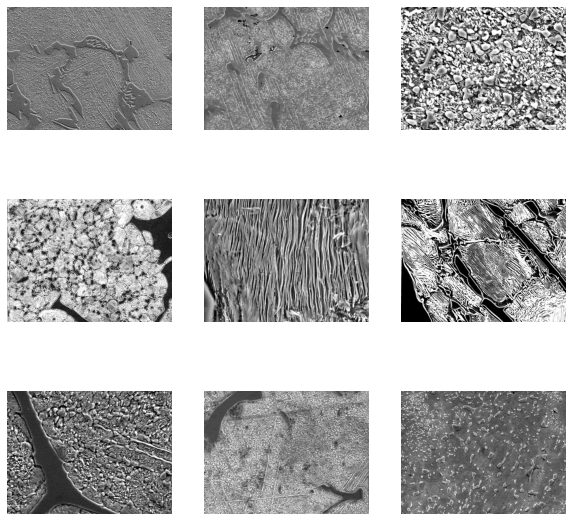

In [7]:
class_names = train.class_names

plt.figure(figsize=(10,10))
for images, labels in train.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype('uint8'))
        #plt.title(class_names[labels[i]]
        plt.axis('off')

In [8]:
val_batches = tf.data.experimental.cardinality(validation)
test = validation.take(val_batches // 5)
validation = validation.skip(val_batches // 5)

In [9]:
print('Number of validation batches: %d' % tf.data.experimental.cardinality(validation))
print('Number of test batches: %d' % tf.data.experimental.cardinality(test))

Number of validation batches: 5
Number of test batches: 1


In [10]:
AUTOTUNE = tf.data.AUTOTUNE

train = train.prefetch(buffer_size=AUTOTUNE)
validation = validation.prefetch(buffer_size=AUTOTUNE)
test = test.prefetch(buffer_size=AUTOTUNE)

In [11]:
# DATA AUGMENTATION

In [12]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal_and_vertical'),
    tf.keras.layers.RandomRotation(0.2)
])

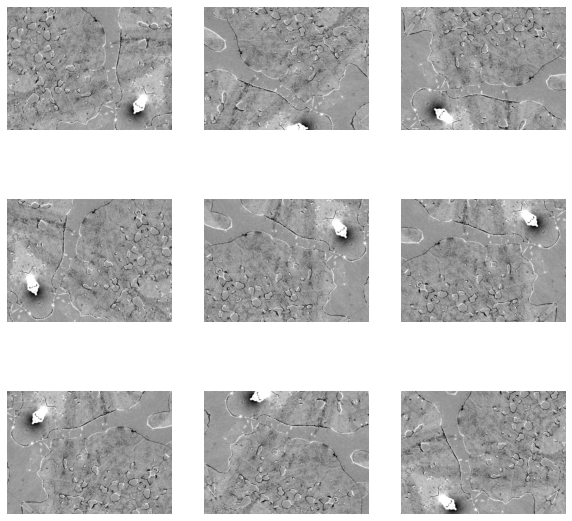

In [13]:
for image, _ in train.take(1):
    plt.figure(figsize=(10,10))
    first_image = image[0]
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
        plt.imshow(augmented_image[0] / 255, cmap='gray')
        plt.axis('off')

In [14]:
# MOBILENET EXPECTS PIXEL VALUES BETWEEN -1 AND 1, SO WE NEED TO RESCALE THE IMAGES

In [15]:
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

In [16]:
rescale = tf.keras.layers.Rescaling(1./127.5, offset=-1)

In [17]:
IMG_SHAPE = (484,645) + (3,)
base_model = tf.keras.applications.MobileNetV2(input_shape=IMG_SHAPE,
                                              include_top=False,
                                              weights='imagenet')

# TESTAR COM IMAGENS QUADRADAS

9420800/9406464 [==============================] - 0s 0us/step


In [18]:
image_batch, label_batch = next(iter(train))
feature_batch = base_model(image_batch)
print(feature_batch.shape)

(32, 16, 21, 1280)


In [19]:
# FEATURE EXTRACTION

In [20]:
base_model.trainable = False

In [21]:
base_model.summary()

Model: "mobilenetv2_1.00_224"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 484, 645, 3  0           []                               
                                )]                                                                
                                                                                                  
 Conv1 (Conv2D)                 (None, 242, 323, 32  864         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 bn_Conv1 (BatchNormalization)  (None, 242, 323, 32  128         ['Conv1[0][0]']                  
                                )                                              

In [22]:
# ADDING A CLASSIFICATION HEAD
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
feature_batch_average = global_average_layer(feature_batch)
print(feature_batch_average.shape)

(32, 1280)


In [23]:
# APPLYING A DENSE LAYER
prediction_layer = tf.keras.layers.Dense(6)
prediction_batch = prediction_layer(feature_batch_average)
print(prediction_batch.shape)

(32, 6)


In [24]:
# BUILDING THE MODEL
inputs = tf.keras.Input(shape=(484, 645,3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = global_average_layer(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = prediction_layer(x)
model = tf.keras.Model(inputs, outputs)

In [25]:
# COMPILING THE MODEL
base_learning_rate = 0.0001
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
             loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
             metrics=['accuracy'])

In [26]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 484, 645, 3)]     0         
                                                                 
 sequential (Sequential)     (None, 484, 645, 3)       0         
                                                                 
 tf.math.truediv (TFOpLambda  (None, 484, 645, 3)      0         
 )                                                               
                                                                 
 tf.math.subtract (TFOpLambd  (None, 484, 645, 3)      0         
 a)                                                              
                                                                 
 mobilenetv2_1.00_224 (Funct  (None, 16, 21, 1280)     2257984   
 ional)                                                          
                                                             

In [27]:
len(model.trainable_variables)

2

In [28]:
# TRAINING THE MODEL
initial_epochs = 10
loss0, accuracy0 = model.evaluate(validation)

5/5 [==============================] - 39s 5s/step - loss: 1.6943 - accuracy: 0.2452


In [29]:
print('Initial loss: {:.2f}'.format(loss0))
print('Initial accuracy: {:.2f}'.format(accuracy0))

Initial loss: 1.69
Initial accuracy: 0.25


In [30]:
history = model.fit(train,
                   epochs=initial_epochs,
                   validation_data=validation)

Epoch 1/10
18/18 [==============================] - 151s 8s/step - loss: 1.5160 - accuracy: 0.3547 - val_loss: 1.2950 - val_accuracy: 0.5742
Epoch 2/10
18/18 [==============================] - 149s 8s/step - loss: 1.3149 - accuracy: 0.5134 - val_loss: 1.1093 - val_accuracy: 0.6323
Epoch 3/10
18/18 [==============================] - 145s 8s/step - loss: 1.1998 - accuracy: 0.5544 - val_loss: 1.0722 - val_accuracy: 0.6000
Epoch 4/10
18/18 [==============================] - 148s 8s/step - loss: 1.1388 - accuracy: 0.5829 - val_loss: 1.0169 - val_accuracy: 0.6323
Epoch 5/10
18/18 [==============================] - 153s 8s/step - loss: 1.0812 - accuracy: 0.6025 - val_loss: 0.9816 - val_accuracy: 0.6645
Epoch 6/10
18/18 [==============================] - 149s 8s/step - loss: 1.0223 - accuracy: 0.6292 - val_loss: 0.8664 - val_accuracy: 0.7290
Epoch 7/10
18/18 [==============================] - 149s 8s/step - loss: 0.9731 - accuracy: 0.6667 - val_loss: 0.9038 - val_accuracy: 0.6968
Epoch 8/10
18

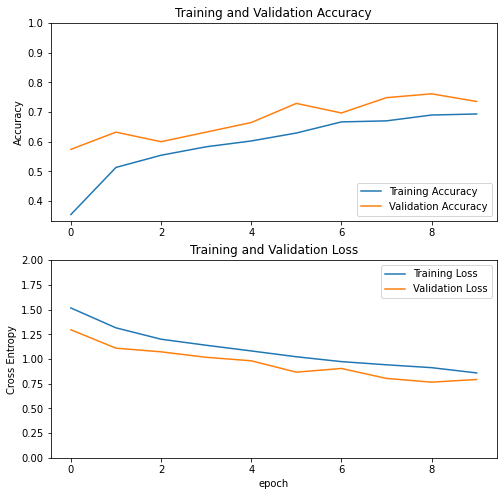

In [31]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,2.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

In [32]:
model.save('model1')

INFO:tensorflow:Assets written to: model1/assets


In [33]:
#model.load_weights('model0')

In [34]:
# MODEL EVALUATION
loss, accuracy = model.evaluate(test)
print('Test Accuracy: ', accuracy)

1/1 [==============================] - 7s 7s/step - loss: 0.6048 - accuracy: 0.8750
Test Accuracy:  0.875


In [35]:
# FINE TUNING 

In [36]:
base_model.trainable = True

In [37]:
print('Number of layers in the base model: ', len(base_model.layers))

fine_tune_at = 100

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

Number of layers in the base model:  154


In [38]:
model.compile(loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
             optimizer=tf.keras.optimizers.RMSprop(learning_rate=base_learning_rate/10),
             metrics=['accuracy'])

In [39]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 484, 645, 3)]     0         
                                                                 
 sequential (Sequential)     (None, 484, 645, 3)       0         
                                                                 
 tf.math.truediv (TFOpLambda  (None, 484, 645, 3)      0         
 )                                                               
                                                                 
 tf.math.subtract (TFOpLambd  (None, 484, 645, 3)      0         
 a)                                                              
                                                                 
 mobilenetv2_1.00_224 (Funct  (None, 16, 21, 1280)     2257984   
 ional)                                                          
                                                             

In [40]:
len(model.trainable_variables)

56

In [ ]:
fine_tune_epochs = 10
total_epochs = initial_epochs + fine_tune_epochs

history_fine = model.fit(train,
                        epochs=total_epochs,
                        initial_epoch=history.epoch[-1],
                        validation_data=validation)

Epoch 10/20
18/18 [==============================] - 235s 13s/step - loss: 0.2347 - accuracy: 0.7380 - val_loss: 0.1621 - val_accuracy: 0.8323
Epoch 11/20
18/18 [==============================] - 240s 13s/step - loss: 0.1839 - accuracy: 0.7950 - val_loss: 0.1460 - val_accuracy: 0.8516
Epoch 12/20
18/18 [==============================] - 234s 13s/step - loss: 0.1622 - accuracy: 0.8289 - val_loss: 0.1394 - val_accuracy: 0.8581
Epoch 13/20
18/18 [==============================] - 239s 13s/step - loss: 0.1533 - accuracy: 0.8271 - val_loss: 0.1316 - val_accuracy: 0.8516
Epoch 14/20
18/18 [==============================] - 239s 13s/step - loss: 0.1430 - accuracy: 0.8414 - val_loss: 0.1179 - val_accuracy: 0.8903
Epoch 15/20
18/18 [==============================] - 235s 13s/step - loss: 0.1397 - accuracy: 0.8503 - val_loss: 0.1231 - val_accuracy: 0.8645
Epoch 16/20
18/18 [==============================] - 235s 13s/step - loss: 0.1332 - accuracy: 0.8627 - val_loss: 0.1282 - val_accuracy: 0.8516

In [ ]:
model.save('model1')

INFO:tensorflow:Assets written to: model1/assets


In [ ]:
acc += history_fine.history['accuracy']
val_acc += history_fine.history['val_accuracy']

#loss += history_fine.history['loss']
val_loss += history_fine.history['val_loss']

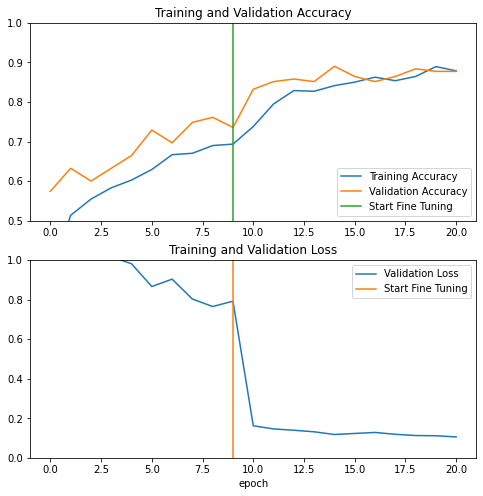

In [ ]:
plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.ylim([0.5, 1])
plt.plot([initial_epochs-1,initial_epochs-1],
          plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
#plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.ylim([0, 1.0])
plt.plot([initial_epochs-1,initial_epochs-1],
         plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

In [ ]:
# EVALUATION AND PREDICTION

In [ ]:
loss, accuracy = model.evaluate(test)
print('Test accuracy :', accuracy)

In [ ]:
# Retrieve a batch of images from the test set
image_batch, label_batch = test.as_numpy_iterator().next()
predictions = model.predict_on_batch(image_batch).flatten()

# Apply a sigmoid since our model returns logits
predictions = tf.nn.sigmoid(predictions)
predictions = tf.where(predictions < 0.5, 0, 1)

print('Predictions:\n', predictions.numpy())
print('Labels:\n', label_batch)

plt.figure(figsize=(10, 10))
for i in range(9):
  ax = plt.subplot(3, 3, i + 1)
  plt.imshow(image_batch[i].astype("uint8"))
  plt.title(class_names[predictions[i]])
  plt.axis("off")